In [9]:
import pandas as pd
import mat73
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem

In [10]:
subj = 'cpeeg02'

mat_path1 = r'C:\Users\fkamdar\Desktop\repos\data\cp_beh_data\Results_CPEEG02_S1_C1_B2_2026-03-23.mat'
condition1 = 'off stim' # ses01
data1 = mat73.loadmat(mat_path1)

mat_path2 = r'C:\Users\fkamdar\Desktop\repos\data\cp_beh_data\Results_CPEEG02_S2_C2_B2_2026-05-11.mat'
condition2 = 'dorsal stim' # ses02
data2 = mat73.loadmat(mat_path2)

mat_path3 = r'C:\Users\fkamdar\Desktop\repos\data\cp_beh_data\Results_CPEEG02_S3_C3_B2_2026-06-17.mat'
condition3 = 'ventral stim' # ses03
data3 = mat73.loadmat(mat_path3)

manifest_ses01 = pd.read_csv("C:\\Users\\fkamdar\\Desktop\\repos\\data\\cp_beh_data\\cpeeg02_block_96_used this in sess01.csv")
manifest_ses02 = pd.read_csv("C:\\Users\\fkamdar\\Desktop\\repos\\data\\cp_beh_data\\cpeeg02_session_2_used this in sess02.csv")
manifest_ses03 = pd.read_csv("C:\\Users\\fkamdar\\Desktop\\repos\\data\\cp_beh_data\\cpeeg02_session_3_used this in ses03.csv")

ERROR:root:ERROR: MATLAB type not supported: Device, (uint32)
ERROR:root:ERROR: MATLAB type not supported: Device, (uint32)


In [11]:
# Session 1
results_cpeeg02_ses01 = data1['Results']  # adjust key name if needed
trials_cpeeg02_ses01 = pd.DataFrame(results_cpeeg02_ses01['Trials'])
trials_cpeeg02_ses01['ImageIndex'] = trials_cpeeg02_ses01['ImageIndex'].astype(int)
merged_df_ses01 = pd.merge(trials_cpeeg02_ses01, manifest_ses01, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses01.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses01.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses01 = merged_df_ses01.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'cue'
})

# Session 2
results_cpeeg02_ses02 = data2['Results']  # adjust key name if needed
trials_cpeeg02_ses02 = pd.DataFrame(results_cpeeg02_ses02['Trials'])
trials_cpeeg02_ses02['ImageIndex'] = trials_cpeeg02_ses02['ImageIndex'].astype(int)
merged_df_ses02 = pd.merge(trials_cpeeg02_ses02, manifest_ses02, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses02.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses02.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses02 = merged_df_ses02.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'cue'
})

# Session 3
results_cpeeg02_ses03 = data3['Results']  # adjust key name if needed
trials_cpeeg02_ses03 = pd.DataFrame(results_cpeeg02_ses03['Trials'])
trials_cpeeg02_ses03['ImageIndex'] = trials_cpeeg02_ses03['ImageIndex'].astype(int)
merged_df_ses03 = pd.merge(trials_cpeeg02_ses03, manifest_ses03, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses03.drop(columns=['trial'], inplace=True)  # drop the redundant 'trial' column from manifest
merged_df_ses03.drop(columns=['condition'], inplace=True)  # drop the redundant 'condition' column from manifest
merged_df_ses03 = merged_df_ses03.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'cue'
})

In [22]:
def plot_valence_vs_normative(merged_df, condition, subj, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    normative_ratings = merged_df['normative_rating'].values
    valence_ratings = merged_df['participant_rating'].values
    normative_ratings = pd.to_numeric(pd.Series(normative_ratings), errors='coerce').to_numpy(dtype=float)
    valence_ratings = pd.to_numeric(pd.Series(valence_ratings), errors='coerce').to_numpy(dtype=float)

    mask = ~np.isnan(normative_ratings) & ~np.isnan(valence_ratings)
    num_valence_nans = np.isnan(valence_ratings).sum()
    norm_vals_clean = normative_ratings[mask]
    valence_clean = valence_ratings[mask]

    ax.scatter(norm_vals_clean, valence_clean, alpha=0.7)

    coeffs = np.polyfit(norm_vals_clean, valence_clean, 1)
    fit_fn = np.poly1d(coeffs)
    x_fit = np.linspace(norm_vals_clean.min(), norm_vals_clean.max(), 100)

    ax.plot(x_fit, fit_fn(x_fit), color='red', linewidth=2, label='Linear fit')
    ax.plot(x_fit, x_fit, color='gray', linestyle='-', linewidth=2, label='y = x')
    ax.legend(loc='upper left', bbox_to_anchor=(0, 1))
    ax.set_xlabel('Normative Ratings')
    ax.set_ylabel('Valence Ratings')
    ax.set_title(f'{condition} {subj} Valence Ratings')
    ax.set_xticks(np.arange(1, 10, 1))
    ax.set_yticks(np.arange(1, 10, 1))
    ax.set_xlim(1, 9)
    ax.set_ylim(0, 10)
    #ax.text(0.75, 0.15, f'Number of NaNs: {num_valence_nans}', fontsize=10, color='red', transform=ax.transAxes)
    #num_trials = len(merged_df)
    #ax.text(0.75, 0.15, f'Number of Trials: {num_trials}', fontsize=10, color='red', transform=ax.transAxes)
    ax.grid(True)

    return ax

<Axes: title={'center': 'ventral stim cpeeg02 Valence Ratings'}, xlabel='Normative Ratings', ylabel='Valence Ratings'>

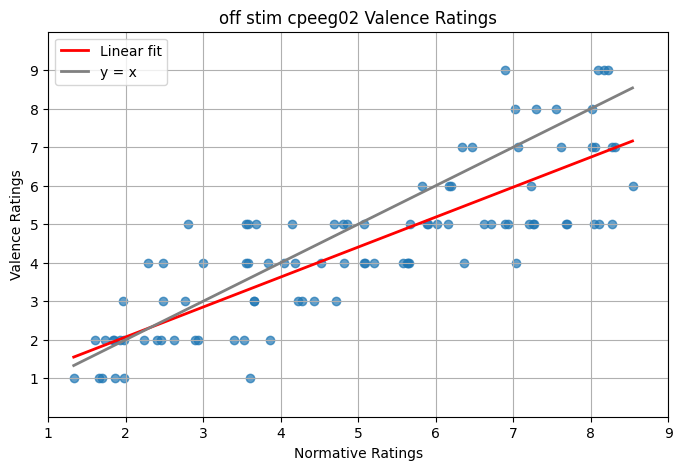

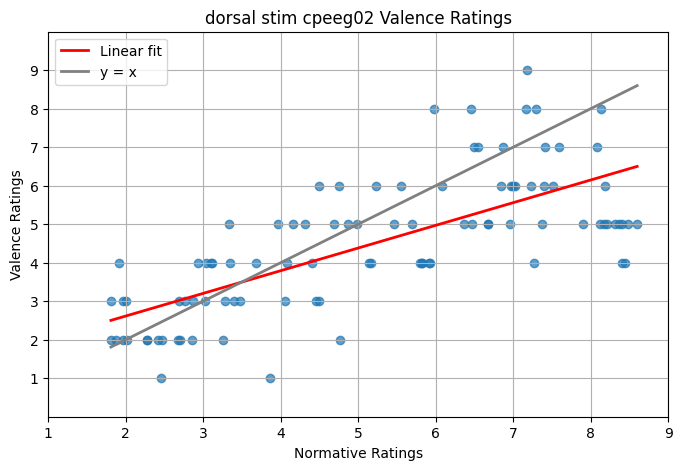

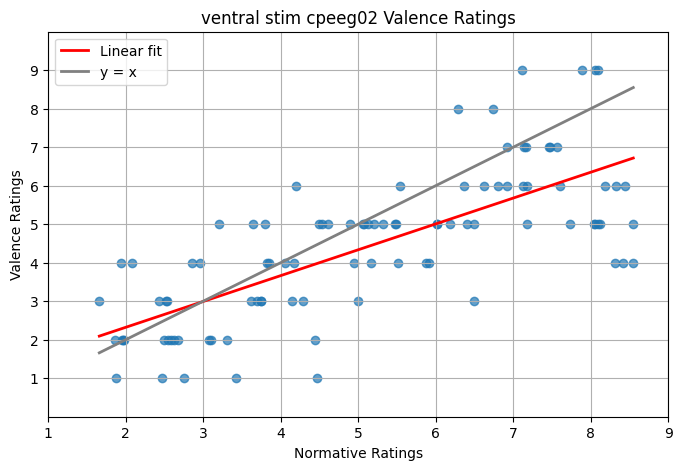

In [23]:
# Fig 1 - ALL ratings for all 3 sessions
plot_valence_vs_normative(merged_df_ses01, condition1, subj)
plot_valence_vs_normative(merged_df_ses02, condition2, subj)
plot_valence_vs_normative(merged_df_ses03, condition3, subj)

In [ ]:
sessions = [
    (condition1, merged_df_ses01),
    (condition2, merged_df_ses02),
    (condition3, merged_df_ses03),
]

for sess_label, df in sessions:
    feel_trials = df[df['cue'] == 'FEEL']
    tone_trials = df[df['cue'] == 'TONE']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_valence_vs_normative(feel_trials,sess_label, 'FEEL', ax=axes[0])
    plot_valence_vs_normative(tone_trials,  sess_label,'TONE',  ax=axes[1])
    plt.tight_layout()
    plt.show()

In [60]:
cue_types = {'FEEL', 'TONE'}
cue_types = list({'FEEL', 'TONE'})
print(cue_types[0])
print(cue_types[1])

TONE
FEEL


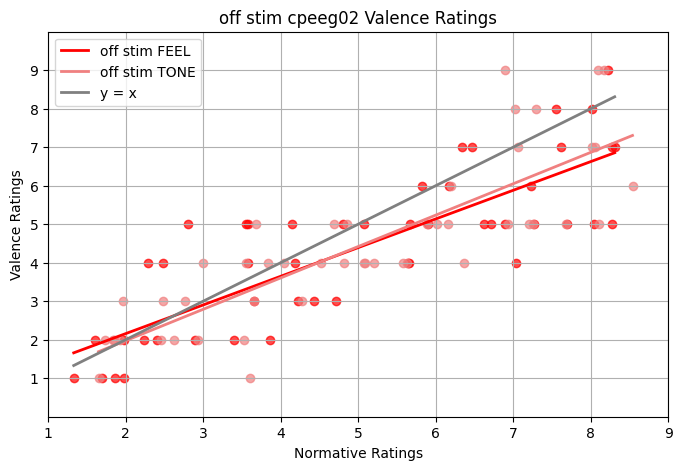

In [ ]:
feel_trials = merged_df_ses01[merged_df_ses01['cue'] == cue_types[1]]
tone_trials = merged_df_ses01[merged_df_ses01['cue'] == cue_types[0]]

# Feel trials
normative_ratings = feel_trials['normative_rating'].values
valence_ratings = feel_trials['participant_rating'].values
normative_ratings = pd.to_numeric(pd.Series(normative_ratings), errors='coerce').to_numpy(dtype=float)
valence_ratings = pd.to_numeric(pd.Series(valence_ratings), errors='coerce').to_numpy(dtype=float)
mask = ~np.isnan(normative_ratings) & ~np.isnan(valence_ratings)
num_valence_nans = np.isnan(valence_ratings).sum()
norm_vals_clean = normative_ratings[mask]
valence_clean = valence_ratings[mask]

# Tone trials
tone_normative_ratings = tone_trials['normative_rating'].values
tone_valence_ratings = tone_trials['participant_rating'].values
tone_normative_ratings = pd.to_numeric(pd.Series(tone_normative_ratings), errors='coerce').to_numpy(dtype=float)
tone_valence_ratings = pd.to_numeric(pd.Series(tone_valence_ratings), errors='coerce').to_numpy(dtype=float)
tone_mask = ~np.isnan(tone_normative_ratings) & ~np.isnan(tone_valence_ratings)
tone_num_valence_nans = np.isnan(tone_valence_ratings).sum()
tone_norm_vals_clean = tone_normative_ratings[tone_mask]
tone_valence_clean = tone_valence_ratings[tone_mask]

fig, ax = plt.subplots(figsize=(8, 5))

# Feel: red
ax.scatter(norm_vals_clean, valence_clean, alpha=0.7, color='red')
coeffs = np.polyfit(norm_vals_clean, valence_clean, 1)
fit_fn = np.poly1d(coeffs)
x_fit = np.linspace(norm_vals_clean.min(), norm_vals_clean.max(), 100)
ax.plot(x_fit, fit_fn(x_fit), color='red', linewidth=2, label=f'{condition1} {cue_types[1]}')

# Tone: light red
ax.scatter(tone_norm_vals_clean, tone_valence_clean, alpha=0.7, color='lightcoral')
tone_coeffs = np.polyfit(tone_norm_vals_clean, tone_valence_clean, 1)
tone_fit_fn = np.poly1d(tone_coeffs)
tone_x_fit = np.linspace(tone_norm_vals_clean.min(), tone_norm_vals_clean.max(), 100)
ax.plot(tone_x_fit, tone_fit_fn(tone_x_fit), color='lightcoral', linewidth=2, label=f'{condition1} {cue_types[0]}')

#ax.plot(x_fit, x_fit, color='gray', linestyle='-', linewidth=2, label='y = x')
ax.legend(loc='upper left', bbox_to_anchor=(0, 1))
ax.set_xlabel('Normative Ratings')
ax.set_ylabel('Valence Ratings')
ax.set_title(f'{condition1} {subj} Valence Ratings')
ax.set_xticks(np.arange(1, 10, 1))
ax.set_yticks(np.arange(1, 10, 1))
ax.set_xlim(1, 9)
ax.set_ylim(0, 10)
#ax.text(0.75, 0.15, f'Number of NaNs: {num_valence_nans}', fontsize=10, color='red', transform=ax.transAxes)
#num_trials = len(merged_df)
#ax.text(0.75, 0.15, f'Number of Trials: {num_trials}', fontsize=10, color='red', transform=ax.transAxes)
ax.grid(True)

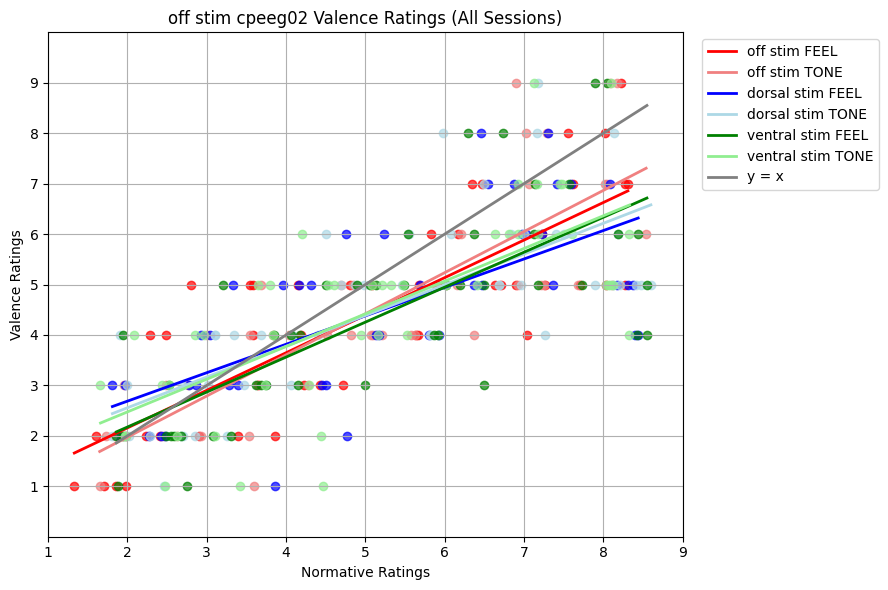

In [66]:
# Config: session dataframes, labels, and color pairs (feel color, tone color)
session_dfs = [merged_df_ses01, merged_df_ses02, merged_df_ses03]
condition_labels = [condition1, condition2, condition3]
session_colors = [
    ('red', 'lightcoral'),
    ('blue', 'lightblue'),
    ('green', 'lightgreen'),
]

fig, ax = plt.subplots(figsize=(9, 6))

for i in range(len(session_dfs)):
    merged_df = session_dfs[i]
    condition_label = condition_labels[i]
    feel_color, tone_color = session_colors[i]

    feel_trials = merged_df[merged_df['cue'] == cue_types[1]]
    tone_trials = merged_df[merged_df['cue'] == cue_types[0]]

    # Feel trials
    normative_ratings = feel_trials['normative_rating'].values
    valence_ratings = feel_trials['participant_rating'].values
    normative_ratings = pd.to_numeric(pd.Series(normative_ratings), errors='coerce').to_numpy(dtype=float)
    valence_ratings = pd.to_numeric(pd.Series(valence_ratings), errors='coerce').to_numpy(dtype=float)
    mask = ~np.isnan(normative_ratings) & ~np.isnan(valence_ratings)
    norm_vals_clean = normative_ratings[mask]
    valence_clean = valence_ratings[mask]

    # Tone trials
    tone_normative_ratings = tone_trials['normative_rating'].values
    tone_valence_ratings = tone_trials['participant_rating'].values
    tone_normative_ratings = pd.to_numeric(pd.Series(tone_normative_ratings), errors='coerce').to_numpy(dtype=float)
    tone_valence_ratings = pd.to_numeric(pd.Series(tone_valence_ratings), errors='coerce').to_numpy(dtype=float)
    tone_mask = ~np.isnan(tone_normative_ratings) & ~np.isnan(tone_valence_ratings)
    tone_norm_vals_clean = tone_normative_ratings[tone_mask]
    tone_valence_clean = tone_valence_ratings[tone_mask]

    # Feel
    ax.scatter(norm_vals_clean, valence_clean, alpha=0.7, color=feel_color)
    coeffs = np.polyfit(norm_vals_clean, valence_clean, 1)
    fit_fn = np.poly1d(coeffs)
    x_fit = np.linspace(norm_vals_clean.min(), norm_vals_clean.max(), 100)
    ax.plot(x_fit, fit_fn(x_fit), color=feel_color, linewidth=2, label=f'{condition_label} {cue_types[1]}')

    # Tone
    ax.scatter(tone_norm_vals_clean, tone_valence_clean, alpha=0.7, color=tone_color)
    tone_coeffs = np.polyfit(tone_norm_vals_clean, tone_valence_clean, 1)
    tone_fit_fn = np.poly1d(tone_coeffs)
    tone_x_fit = np.linspace(tone_norm_vals_clean.min(), tone_norm_vals_clean.max(), 100)
    ax.plot(tone_x_fit, tone_fit_fn(tone_x_fit), color=tone_color, linewidth=2, label=f'{condition_label} {cue_types[0]}')

ax.plot(x_fit, x_fit, color='gray', linestyle='-', linewidth=2, label='y = x')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_xlabel('Normative Ratings')
ax.set_ylabel('Valence Ratings')
ax.set_title(f'{condition1} {subj} Valence Ratings (All Sessions)')
ax.set_xticks(np.arange(1, 10, 1))
ax.set_yticks(np.arange(1, 10, 1))
ax.set_xlim(1, 9)
ax.set_ylim(0, 10)
ax.grid(True)

plt.tight_layout()

In [ ]:
#NEXT TIME: LINEAR MIXED EFFECTS MODEL
# model stim condition and cue type

In [26]:
# plot by cue for all 3 sessions
print(merged_df_ses03.head())


    cue      CueText  ImageIndex          RT_Valence participant_rating  \
0  FEEL  Feel freely           1   5.927786300017033                2.0   
1  FEEL  Feel freely           2  2.7286177999922074                2.0   
2  TONE    Tone down           3  3.6864111000322737                2.0   
3  FEEL  Feel freely           4    2.03236489999108                3.0   
4  TONE    Tone down           5  2.6363722000387497                5.0   

              ID           filename Category  normative_rating val_bin  
0   People_121_h   People_121_h.jpg   People              3.31     3-4  
1           9911           9911.jpg  Objects              1.95     1-2  
2  Animals_008_v  Animals_008_v.jpg  Animals              2.63     2-3  
3  Animals_012_h  Animals_012_h.jpg  Animals              3.62     3-4  
4  Animals_044_h  Animals_044_h.jpg  Animals              5.32     5-6  


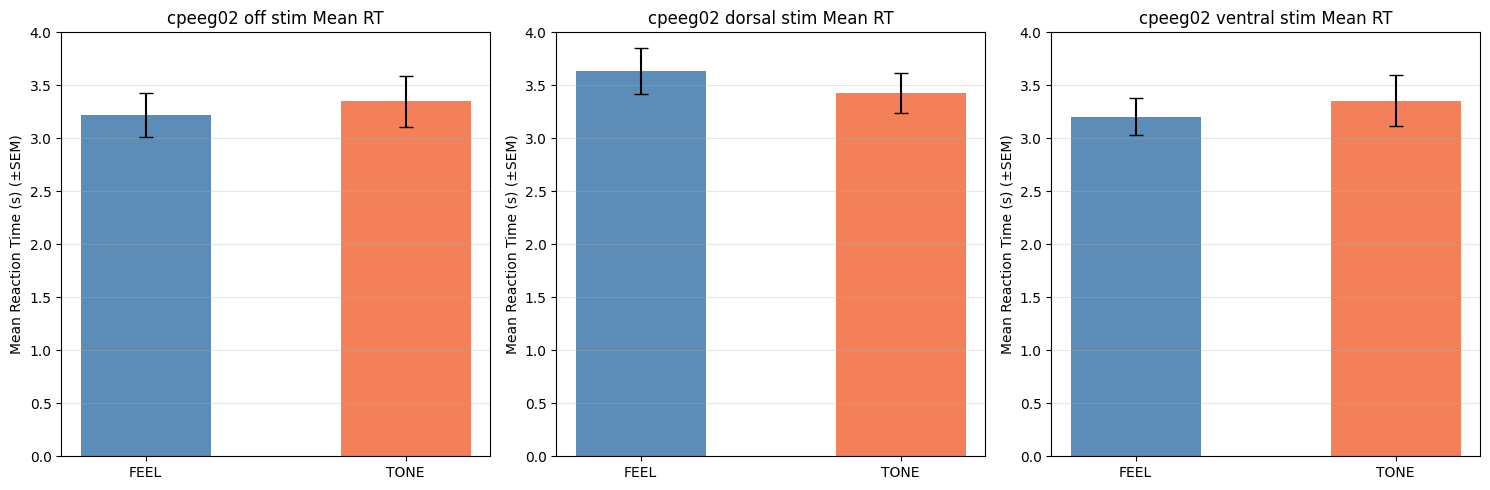

In [35]:
# plot mean +- sem reaction times for all feel and tone trials for all 3 sessions
mean_rt_feel_ses01 = merged_df_ses01[merged_df_ses01['cue'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses01 = merged_df_ses01[merged_df_ses01['cue'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses02 = merged_df_ses02[merged_df_ses02['cue'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses02 = merged_df_ses02[merged_df_ses02['cue'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses03 = merged_df_ses03[merged_df_ses03['cue'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses03 = merged_df_ses03[merged_df_ses03['cue'] == 'TONE']['RT_Valence'].mean()


def plot_rt_bar(merged_df, sess_label, ax):
    feel_rt = merged_df[merged_df['cue'] == 'FEEL']['RT_Valence'].dropna()
    tone_rt = merged_df[merged_df['cue'] == 'TONE']['RT_Valence'].dropna()

    means = [feel_rt.mean(), tone_rt.mean()]
    sems = [sem(feel_rt), sem(tone_rt)]

    ax.bar(['FEEL', 'TONE'], means, yerr=sems, capsize=5,
           color=['#5b8db8', '#f4805a'], width=0.5)

    ax.set_ylim(0, 4)
    ax.set_title(f'{subj} {sess_label} Mean RT')
    ax.set_ylabel('Mean Reaction Time (s) (±SEM)')
    ax.grid(True, axis='y', alpha=0.3)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sessions = [
    (condition1, merged_df_ses01),
    (condition2, merged_df_ses02),
    (condition3, merged_df_ses03),
]

for (sess_label, df), ax in zip(sessions, axes):
    plot_rt_bar(df, sess_label, ax)

plt.tight_layout()
plt.show()
